# Resting Batch Face 

### Från 😐 till 😡 med Convolutional Neural Networks

----

I detta projekt utvecklas flera CNN-modell för klassificering av ansiktsuttryck med hjälp av FER-2013-datasetet. 

Notebooken går igenom hela processen från dataanalys och förbehandling till modellträning, utvärdering och prediktioner på ny data, samt en analys och reflektion kring modellernas olika resultat.

In [11]:
# --- SETUP & IMPORTS ---

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from pathlib import Path

from PIL import Image

import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

## 1. Dataanalys

### 1.1 Antal bilder

#### 1.1.1 Total, Train & Test

In [12]:
def count_images(path):
    """
    Funktion för att räkna antalet filer som slutar på .jpg eller .png i en given mapp.

    path (Path):
        En pathlib.Path-sökväg till mappen som ska "skannas"

    Returnerar totalt antal bilder hittade i mappen (och dess undermappar) (int)
    """
    return len(list(path.rglob("*.jpg"))) + len(list(path.rglob("*jpeg"))) + len(list(path.rglob("*.png")))

# Skapar sökväg till huvudmappen
data_dir = Path("data")

# Räknar antalet bilder i mapparna data, train och test
train_count = count_images(data_dir / "train")
test_count = count_images(data_dir / "test")
total_count = train_count + test_count

# Räknar ut andel 
train_percent = (train_count / total_count) * 100
test_percent = (test_count / total_count) * 100
total_percent = train_percent + test_percent

# Skapar data till statestik-tabell
stats_images = {
    "Set": ["Train", "Test", "Total"],
    "Antal bilder": [train_count, test_count, total_count],
    "Andel": [f"{train_percent:.1f}%", f"{test_percent:.1f}%", f"{total_percent:.1f}%"]
}

df_stats_images = pd.DataFrame(stats_images)

df_stats_images

,Set,Antal bilder,Andel
0,Train,28691,80.0%
1,Test,7178,20.0%
2,Total,35869,100.0%


https://docs.python.org/3/library/pathlib.html

https://www.geeksforgeeks.org/python/pathlib-module-in-python/ 

Path från pathlib är det enklare och mer moderna sättet att hantera sökvägar jämfört med os.path då pathlib hanterar sökvägarna som objekt istället för vanliga strängar. 

Path-objekt kommer med en metod rglob() vilket gör det möjligt att leta vidare i undermappar (och FER-2013 verkar inte bestå av annat än mappar hit och dit). 

Motsvarigheten till rglob() är bara glob() som "stannar" vid första mappen istället för att gå djupare ner i mappstrukturen.

rglob() returnerar en så kallad generator, vilket bara "går förbi" filerna i mapparna och lägger inte dem på minnet. 

list() behövs då för att generatorn ska faktiskt ska samla på sig alla bilder så att det sen går att räkna dem med len().

#### 1.1.2 Klasserna

In [13]:
def get_class_dataframe(folder_path, total_set_count):
    """
    Skapar en DataFrame med statistik för alla klasser (undermappar).

    folder_path:
        Sökvägen till mappen.
    
    total_set_count:
        Totala antalet bilder i den mappen (för att räkna ut andel).

    Returnerar en pd.DataFrame
    """

    stats_list = []
    stray_files_found = []

    # Loop för att gå igenom varje undermapp och ta ut statistik för den (= antalet bilder)
    for class_path in sorted(folder_path.iterdir()):
        if class_path.is_dir():
            count = count_images(class_path)
            percent = (count / total_set_count) * 100

            stats_list.append({
                "Klass": class_path.name,
                "Antal": count,
                "Andel": f"{percent:.1f}%"
            })
        else:
            stray_files_found.append(class_path.name)

    if stray_files_found:
        print(f"Meddelande för '{folder_path.name}': Det finns filer utanför mapparna.")
    else:
        print(f"Meddelande för '{folder_path.name}': Det finns inga filer utanför mapparna.")

    return pd.DataFrame(stats_list)

iterdir() "öppnar" mappen i fråga (i den här rapporten antingen "train" eller "test") och säger vilka andra mappar som finns i den, alltså klasserna. På så vis får vi klassnamnen. 

sorted() gör att loopen går igenom undermapparna i bokstavsordning (så det alltid blir samma ordning).

is_dir() kontrollerar att det är en mapp. Om det inte är en mapp läggs filen i listan stray_files_found. 

Om det är en mapp används funktionen count_images för att räkna antalet bilder för den aktuella klassmappen. 

Varje klassinformation sparas som en dictionary i listan stats_list för att det ska gå enkelt att göra en pd.DataFrame sen. 

Och på slutet så ligger det en kontroll som talar om att det finns eller inte finns lösa filer utanför mapparna. (En liten check för att se hur städad datan är)

In [14]:
# Skriver ut statistik-tabellen för "train"
df_train = get_class_dataframe(data_dir / "train", train_count)

df_train

Meddelande för 'train': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,3977,13.9%
1,disgust,436,1.5%
2,fear,4097,14.3%
3,happy,7215,25.1%
4,neutral,4965,17.3%
5,sad,4830,16.8%
6,surprise,3171,11.1%


In [15]:
# Skriver ut statistik-tabellen för "test"
df_test = get_class_dataframe(data_dir / "test", test_count)

df_test

Meddelande för 'test': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,958,13.3%
1,disgust,111,1.5%
2,fear,1024,14.3%
3,happy,1774,24.7%
4,neutral,1233,17.2%
5,sad,1247,17.4%
6,surprise,831,11.6%


#### 1.1.3 Slutsats kontroll av antalet bilder

- FER-2013 är vid nedladdning redan uppdelat i tränings- och testdata med en fördelning på 80 % träningsdata och 20 % testdata.
- Det finns en obalans mellan klasserna i "train" där träningsdatan till 25% består av "happy" men bara till 1,5% av "disgust". Övriga klasser är fördelade någorlunda jämnt inom spannet 11-17%.
- Den obalans som råder i "train" ser likadan ut i "test". 


### 1.2 Bildformat

In [16]:
# Går igenom ALLA bilder för att plocka ut alla olika typer av bildstorlekar, bildformat och färgskala. 
all_sizes = set()
all_formats = set()
all_modes = set()

for img_path in data_dir.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        with Image.open(img_path) as img:
            all_sizes.add(img.size)
            all_formats.add(img.format)
            all_modes.add(img.mode)

https://docs.python.org/3/tutorial/datastructures.html#sets 

https://pillow.readthedocs.io/en/stable/reference/Image.html

https://pillow.readthedocs.io/en/stable/reference/open_files.html#file-handling

set() skapar en tom "behållare" som är lite som en lista, fast oordnad och som inte kan innehålla dubletter. Vilket passar bra när jag bara vill veta vilka olika varianter det finns, inte hur många av varje. 

img_path.suffix.lower() säkerställer att koden bara försöker bearbeta filer som faktiskt är bilder (.jpg, .jpeg, .png).

Image.open() skapar ett objekt (i det här fallet img) som gör det möjligt att göra en massa roligt med det objektet/bilden sedan, som exempelvis show() eller resize(). 

Men helt ensam gör den inte så mycket, förutom just *det* som jag vill åt: extrahera bildstorlek, bildformat och färgskala. 

Image.open() lämnar normalt filen öppen liten grann, men genom att använda with stängs den igen vilket gör att det går att kolla igenom 35 000 + bilder utan att datorn exploderar. 

In [17]:
# Skriver ut resultatet från kodcellen innan
print(f"Unika storlekar: {all_sizes}")
print(f"Unika format: {all_formats}")
print(f"Unika modes: {all_modes}")

Unika storlekar: {(48, 48)}
Unika format: {'JPEG'}
Unika modes: {'L'}


#### 1.2.1 Slutsats bildformat

Alla bilder har samma storlek (48 x 48), samma format (jpg) och är i gråskala (L) (motsvarande för färg är RGB).

### 1.3 Visuell kontroll

In [18]:
# Plocka ut fem slumpmässiga bilder från varje klass i "train" och plottar dem i samma figur
random.seed(42)

n_samples = 5
train_path = data_dir / "train"
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])

preview_fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))

for i, label in enumerate(classes):
    class_dir = train_path / label
    all_imgs = list(class_dir.glob("*.jpg"))

    samples = random.sample(all_imgs, n_samples)

    for j, img_path in enumerate(samples):
        with Image.open(img_path) as img:
            ax = axes[i, j]
            ax.imshow(img, cmap="grey")
            ax.axis("off")

            if j == 0:
                ax.set_title(label, loc="left", fontweight="bold")

plt.tight_layout()

plt.close(preview_fig)

train_path = data_dir / "train" skapar en sökväg till träningsmappen. 

classes = sorted([...]) skapar en lista med namnen på alla klasser (undermappar) i bokstavsordning. (Allt som inte är en mapp ignoreras)

preview_fig, axes = ... här skapas en figur med flera rader och kolumner. Eftersom varje rad ska innehålla 5 bilder från de olika klasserna blir antalet rader hur många klasser det finns (len(classes)) och antalet kolumner blir antalet bilder som ska visas (i det här fallet n_samples = 5). 

Sedan startas en loop som går igenom varje klass. i är klassens radnummer i figuren och label är namnet på klassen. 

class_dir = train_path / label skapar en sökväg till den aktuella klassens mapp. 

Alla bilder i den aktuella mappen sparas i en lista, all_imgs. Sedan väljs fem slumpmässiga bilder i listan ut. 

Den inre loopen går igenom de fem valda bilderna. Varje bild öppnas med Image.open() och får en korrekt plats i plotten med ax = axes[i, j] där i = raden (klassen) och ju = kolumnnummer. 

ax.imshow(img) gör att bilden visas i den valda rutan i figuren. ax.axis("off") tar bort axlarna så bara bilden visas. 

Rubriken på varje rad (klassnamnet) skrivs bara ut vid den första bilden i varje rad (j == 0).

Hela figuren sparas i en variabel (preview_fig) för att kunna visa den i den kodcell man vill. Därför behövs också plt.close(preview_fig)

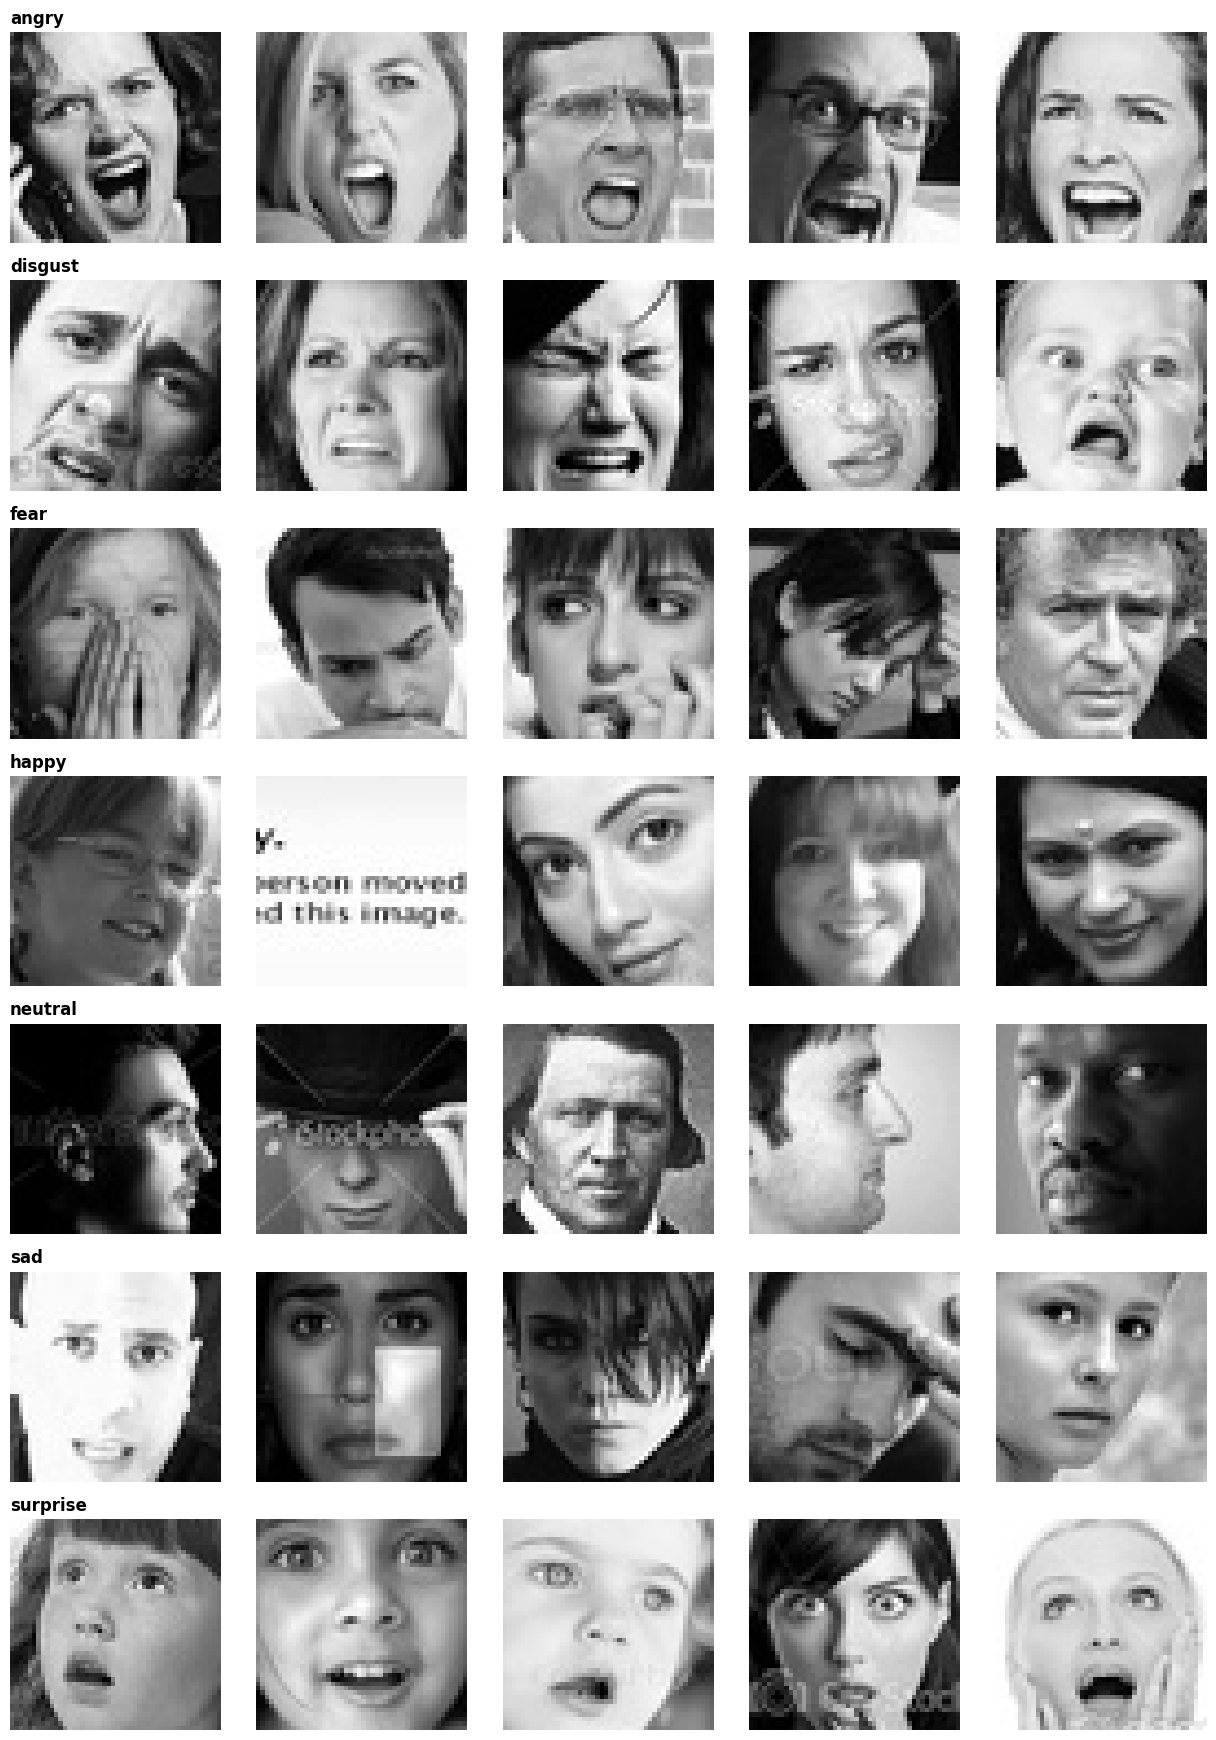

In [19]:
preview_fig

https://arxiv.org/pdf/1307.0414 (rapport om tävlingen som fick FER-2013 att uppstå)

FER-2013 togs fram i samband med en maskininlärningstävling 2013. Datasetet skapades genom att använda Google Image Search API med 184 känslorelaterade sökord, som sedan kategeoriserades i sju känsloklasser: 

- angry
- disgust
- fear
- happy
- sad
- surpries 
- neutral

Jag vill säga att detta i kombination med att tolkning av känslouttryck är subjektivt gör FER-2013 till ett svårt dataset för min NN-modell att sätta tänderna i... 

Bara i dessa 35 slumpmässiga bilder finns det brus som gör det svårt: 

- flera bilder innehåller text
- en bild hann försvinna
- varje rad innehåller minst en bild som mycket väl skulle kunna passa i en eller flera andra klasser  

## 2. Förbehandling

## 3. Modellering och experiment

### 3.1 Modell 1

#### 3.1.1 Modellarkitektur

#### 3.1.2 Träning

#### 3.1.3 Resultat

### 3.2 Modell 2

#### 3.2.1 Transfer Learning

#### 3.2.2 Modellarkitektur

#### 3.2.3 Träning

#### 3.2.4 Resultat

### 3.3 Modell 3

#### 3.3.1 Modellarkitektur

#### 3.3.2 Träning

#### 3.3.3 Resultat

### 3.4 Modell 4

#### 3.4.1 Modellarkitektur

#### 3.4.2 Träning

#### 3.4.3 Resultat

### 3.5 Modell 5

#### 3.5.1 Data Augumentation

#### 3.5.2 Modellarkitektur

#### 3.5.3 Träning

#### 3.5.4 Resultat

## 4. Utvärdering

## 5. Prediktioner på ny data

## 6. Analys av resultatet

## 7. Reflektion